## Introduction

Antimicrobial resistance (AMR) is one of the most significant global public health challenges, threatening the effective prevention and treatment of bacterial infections. The increasing emergence of resistant pathogens has reduced the effectiveness of commonly used antibiotics, resulting in prolonged hospital stays, increased healthcare costs, treatment failures, and higher mortality rates. Among the pathogens of major clinical concern are *Escherichia coli* and *Staphylococcus aureus*, which are responsible for a wide range of community-acquired and hospital-associated infections.

Conventional antimicrobial susceptibility testing (AST) methods are often laboratory-intensive and time-consuming, delaying appropriate treatment decisions. As healthcare systems continue to generate large amounts of microbiological and clinical data, machine learning approaches provide an opportunity to develop predictive systems that can support faster and more informed antibiotic selection.

This project aims to develop two machine learning models for predicting antimicrobial susceptibility patterns in **Escherichia coli** and **Staphylococcus aureus**. The models are designed as multi-target classification systems, where multiple antibiotics are predicted simultaneously and each prediction falls into one of three susceptibility categories: Susceptible (S), Intermediate (I), or Resistant (R).

The study leverages microbiological, demographic, clinical, and resistance gene information to identify patterns associated with antibiotic resistance. Separate models are developed for *E. coli* and *S. aureus* because the organisms differ in resistance mechanisms, clinically relevant antibiotics, and epidemiological characteristics. By predicting susceptibility outcomes across several antibiotics at once, the models aim to capture correlated resistance patterns commonly observed in multidrug-resistant organisms.

Machine learning algorithms such as Random Forest, Decision trees, ExtraTrees, etc., methods will be explored within a multi-output classification framework. The performance of the models will be evaluated using metrics suitable for imbalanced multi-class classification, including accuracy, precision, recall, F1-score, and macro F1-score. Feature importance will also be used to identify the most influential predictors of resistance.

Ultimately, this project seeks to contribute toward data-driven AMR surveillance and clinical decision support by developing predictive tools capable of assisting in antimicrobial susceptibility prediction for clinically important bacterial pathogens.


In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

## ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer


# Multiclass classification metrics
from sklearn.multioutput import MultiOutputClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, hamming_loss
%matplotlib inline

# Reading data

In [2]:
data = pd.read_excel("/home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Data/2025_03_11 atlas_antibiotics.xlsx")
data.head()

,Isolate Id,Study,Species,Family,Country,State,Gender,Age Group,Speciality,Source,...,DHA,FOX,ACTMIR,KPC,OXA,NDM,IMP,VIM,SPM,GIM
0,1000000,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Male,85 and Over,Emergency Room,Urine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1000001,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Female,13 to 18 Years,Emergency Room,Ear,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000002,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Female,65 to 84 Years,Nursing Home / Rehab,Urine,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000003,TEST,Pseudomonas aeruginosa,Non-Enterobacteriaceae,France,NaN,Male,19 to 64 Years,Medicine General,Skin,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000004,TEST,Serratia marcescens,Enterobacteriaceae,France,NaN,Male,19 to 64 Years,Medicine General,Blood,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
atlas = data.copy()

# Codebook

In [ ]:
%run  -i /home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/S- neighbors.RadiusNeighborsClassifiercripts/codebook.py

Codebook generated successfully!


# Final ML dataset Variables

Only selected variables were used for the final ML dataset. These variables were selected based on their relevance to the problem at hand and their potential to provide insights into the data and their availability when the model is deployed. The selected variables are as follows:

**Variables**
1. Ward
2. Specimen type
3. Country
4. Year
5. Organism
6. Antibiotics
7. Age
8. Sex

In [5]:
antibiotics = []
for col in atlas.columns:
    if "_I" in col:
        antibiotics.append(col)

In [6]:
data1 = atlas[['Species','Family','Phenotype','Country','Gender','Age Group','Speciality','Source','In / Out Patient','Year']]

In [7]:
data1.rename(columns={'Species': 'Pathogen', 'Gender':'Sex', 'Speciality':'Ward', 'Source':'Specimen type', 'In / Out Patient': 'In_out_patient'}, inplace=True)

/tmp/ipykernel_4936/3599068948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1.rename(columns={'Species': 'Pathogen', 'Gender':'Sex', 'Speciality':'Ward', 'Source':'Specimen type', 'In / Out Patient': 'In_out_patient'}, inplace=True)


In [8]:
pd.set_option('display.max_columns', None)
ml_data = pd.concat([data1, atlas[antibiotics]], axis=1)
ml_data.head()

,Pathogen,Family,Phenotype,Country,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Azithromycin_I,Cefepime_I,Cefoxitin_I,Ceftazidime_I,Ceftriaxone_I,Clarithromycin_I,Clindamycin_I,Erythromycin_I,Imipenem_I,Levofloxacin_I,Linezolid_I,Meropenem_I,Metronidazole_I,Minocycline_I,Penicillin_I,Piperacillin tazobactam_I,Tigecycline_I,Vancomycin_I,Ampicillin sulbactam_I,Aztreonam_I,Aztreonam avibactam_I,Cefixime_I,Ceftaroline_I,Ceftaroline avibactam_I,Ceftazidime avibactam_I,Ciprofloxacin_I,Colistin_I,Daptomycin_I,Doripenem_I,Ertapenem_I,Gatifloxacin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Quinupristin dalfopristin_I,Sulbactam_I,Teicoplanin_I,Tetracycline_I,Trimethoprim sulfa_I,Ceftolozane tazobactam_I,Cefoperazone sulbactam_I,Meropenem vaborbactam_I,Cefpodoxime_I,Ceftibuten_I,Ceftibuten avibactam_I,Tebipenem_I
0,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Male,85 and Over,Emergency Room,Urine,None Given,2013,Susceptible,NaN,NaN,NaN,Resistant,NaN,Intermediate,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Female,13 to 18 Years,Emergency Room,Ear,None Given,2013,Susceptible,NaN,NaN,NaN,Intermediate,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Female,65 to 84 Years,Nursing Home / Rehab,Urine,None Given,2013,Susceptible,NaN,NaN,NaN,Intermediate,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Resistant,NaN,NaN,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Male,19 to 64 Years,Medicine General,Skin,None Given,2013,Susceptible,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Serratia marcescens,Enterobacteriaceae,NaN,France,Male,19 to 64 Years,Medicine General,Blood,None Given,2013,Susceptible,Resistant,Resistant,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(ml_data.select_dtypes(include='object').columns)

Index(['Pathogen', 'Family', 'Phenotype', 'Country', 'Sex', 'Age Group',
       'Ward', 'Specimen type', 'In_out_patient', 'Amikacin_I',
       'Amoxycillin clavulanate_I', 'Ampicillin_I', 'Azithromycin_I',
       'Cefepime_I', 'Cefoxitin_I', 'Ceftazidime_I', 'Ceftriaxone_I',
       'Clarithromycin_I', 'Clindamycin_I', 'Erythromycin_I', 'Imipenem_I',
       'Levofloxacin_I', 'Linezolid_I', 'Meropenem_I', 'Metronidazole_I',
       'Minocycline_I', 'Penicillin_I', 'Piperacillin tazobactam_I',
       'Tigecycline_I', 'Vancomycin_I', 'Ampicillin sulbactam_I',
       'Aztreonam_I', 'Cefixime_I', 'Ceftaroline_I', 'Ceftazidime avibactam_I',
       'Ciprofloxacin_I', 'Colistin_I', 'Daptomycin_I', 'Doripenem_I',
       'Ertapenem_I', 'Gentamicin_I', 'Moxifloxacin_I', 'Oxacillin_I',
       'Quinupristin dalfopristin_I', 'Teicoplanin_I', 'Tetracycline_I',
       'Trimethoprim sulfa_I', 'Ceftolozane tazobactam_I',
       'Meropenem vaborbactam_I', 'Cefpodoxime_I', 'Ceftibuten_I'],
      dtype='obj

In [10]:
print(ml_data.select_dtypes(include=["int64", "float64"]).columns)

Index(['Year', 'Aztreonam avibactam_I', 'Ceftaroline avibactam_I',
       'Gatifloxacin_I', 'Sulbactam_I', 'Cefoperazone sulbactam_I',
       'Ceftibuten avibactam_I', 'Tebipenem_I'],
      dtype='object')


In [11]:
cols = ['Year','Aztreonam avibactam_I', 'Ceftaroline avibactam_I',
       'Gatifloxacin_I', 'Sulbactam_I', 'Cefoperazone sulbactam_I',
       'Ceftibuten avibactam_I', 'Tebipenem_I']

ml_data[cols] = ml_data[cols].astype('object')

In [12]:
pd.set_option('display.max_columns', None)
ml_data.head()

,Pathogen,Family,Phenotype,Country,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Azithromycin_I,Cefepime_I,Cefoxitin_I,Ceftazidime_I,Ceftriaxone_I,Clarithromycin_I,Clindamycin_I,Erythromycin_I,Imipenem_I,Levofloxacin_I,Linezolid_I,Meropenem_I,Metronidazole_I,Minocycline_I,Penicillin_I,Piperacillin tazobactam_I,Tigecycline_I,Vancomycin_I,Ampicillin sulbactam_I,Aztreonam_I,Aztreonam avibactam_I,Cefixime_I,Ceftaroline_I,Ceftaroline avibactam_I,Ceftazidime avibactam_I,Ciprofloxacin_I,Colistin_I,Daptomycin_I,Doripenem_I,Ertapenem_I,Gatifloxacin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Quinupristin dalfopristin_I,Sulbactam_I,Teicoplanin_I,Tetracycline_I,Trimethoprim sulfa_I,Ceftolozane tazobactam_I,Cefoperazone sulbactam_I,Meropenem vaborbactam_I,Cefpodoxime_I,Ceftibuten_I,Ceftibuten avibactam_I,Tebipenem_I
0,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Male,85 and Over,Emergency Room,Urine,None Given,2013,Susceptible,NaN,NaN,NaN,Resistant,NaN,Intermediate,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Female,13 to 18 Years,Emergency Room,Ear,None Given,2013,Susceptible,NaN,NaN,NaN,Intermediate,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Female,65 to 84 Years,Nursing Home / Rehab,Urine,None Given,2013,Susceptible,NaN,NaN,NaN,Intermediate,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Resistant,NaN,NaN,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Male,19 to 64 Years,Medicine General,Skin,None Given,2013,Susceptible,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Serratia marcescens,Enterobacteriaceae,NaN,France,Male,19 to 64 Years,Medicine General,Blood,None Given,2013,Susceptible,Resistant,Resistant,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualization

In [13]:
%run  -i /home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Scripts/visualizations.py

Numeric variables: Index([], dtype='object')
Categorical variables: Index(['Pathogen', 'Family', 'Phenotype', 'Country', 'Sex', 'Age Group',
       'Ward', 'Specimen type', 'In_out_patient', 'Year', 'Amikacin_I',
       'Amoxycillin clavulanate_I', 'Ampicillin_I', 'Azithromycin_I',
       'Cefepime_I', 'Cefoxitin_I', 'Ceftazidime_I', 'Ceftriaxone_I',
       'Clarithromycin_I', 'Clindamycin_I', 'Erythromycin_I', 'Imipenem_I',
       'Levofloxacin_I', 'Linezolid_I', 'Meropenem_I', 'Metronidazole_I',
       'Minocycline_I', 'Penicillin_I', 'Piperacillin tazobactam_I',
       'Tigecycline_I', 'Vancomycin_I', 'Ampicillin sulbactam_I',
       'Aztreonam_I', 'Aztreonam avibactam_I', 'Cefixime_I', 'Ceftaroline_I',
       'Ceftaroline avibactam_I', 'Ceftazidime avibactam_I', 'Ciprofloxacin_I',
       'Colistin_I', 'Daptomycin_I', 'Doripenem_I', 'Ertapenem_I',
       'Gatifloxacin_I', 'Gentamicin_I', 'Moxifloxacin_I', 'Oxacillin_I',
       'Quinupristin dalfopristin_I', 'Sulbactam_I', 'Teicoplan

<Figure size 640x480 with 0 Axes>

## Data cleaning and preprocessing

### Specimen types


Uncategorized Specimens:
Specimen type
Uncategorized    23

Specimen Types grouped into Categories:
         Specimen type  Count
           Respiratory 262176
    Skin & Soft Tissue 222513
   Blood & Circulatory 184962
     Urinary & Genital 146712
      Gastrointestinal  66641
         General Fluid  52731
                 Other  13846
           HEENT & CNS  13076
Musculoskeletal & Bone   4125
         Uncategorized     23


/tmp/ipykernel_4936/1523467640.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Specimen type', data=categorized_df, palette='Spectral')


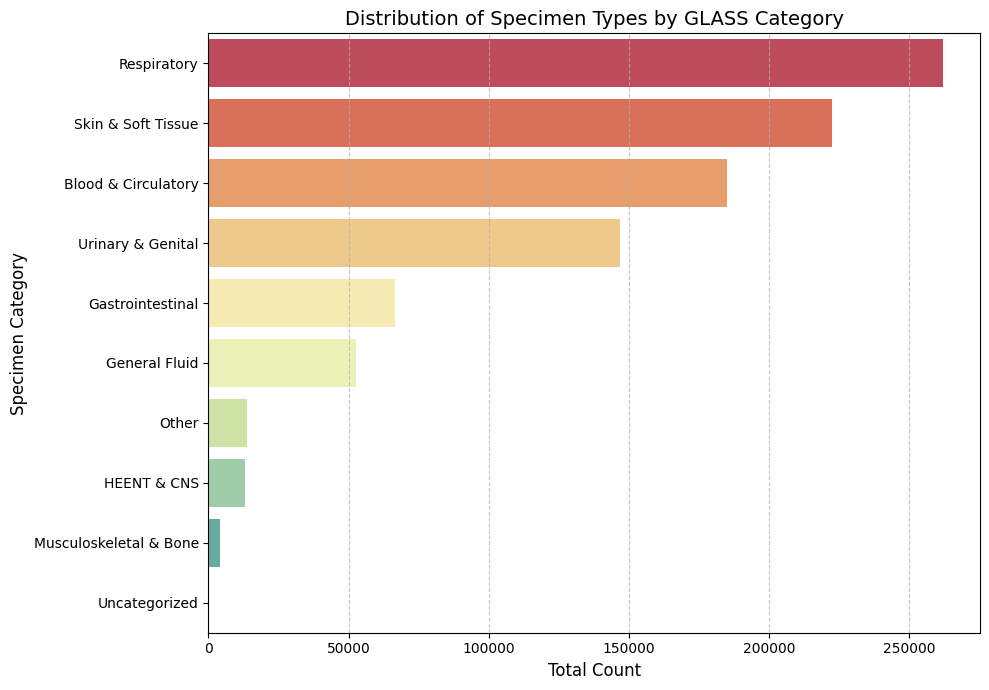

In [14]:
specimen_category_map = {
    # Skin & Soft Tissue
    'Wound': 'Skin & Soft Tissue', 'Abscess': 'Skin & Soft Tissue', 
    'Skin: Other': 'Skin & Soft Tissue', 'Ulcer': 'Skin & Soft Tissue', 
    'Cellulitis': 'Skin & Soft Tissue', 'Decubitus': 'Skin & Soft Tissue', 
    'Burn': 'Skin & Soft Tissue', 'Furuncle': 'Skin & Soft Tissue', 
    'Impetiginous lesions': 'Skin & Soft Tissue', 'Carbuncle': 'Skin & Soft Tissue', 
    'Integumentary (Skin Nail Hair)': 'Skin & Soft Tissue', 'Nails': 'Skin & Soft Tissue', 
    'Hair': 'Skin & Soft Tissue', 'Skin': 'Skin & Soft Tissue',

    # Blood & Circulatory
    'Blood': 'Blood & Circulatory', 'Circulatory: Other': 'Blood & Circulatory', 
    'Blood Vessels': 'Blood & Circulatory', 'Heart': 'Blood & Circulatory', 
    'Bone Marrow': 'Blood & Circulatory', 'Lymph Nodes': 'Blood & Circulatory', 
    'Lymphatic Fluid': 'Blood & Circulatory',

    # Respiratory
    'Sputum': 'Respiratory', 'Endotracheal aspirate': 'Respiratory', 
    'Bronchus': 'Respiratory', 'Bronchoalveolar lavage': 'Respiratory', 
    'Trachea': 'Respiratory', 'Respiratory: Other': 'Respiratory', 
    'Nose': 'Respiratory', 'Lungs': 'Respiratory', 'Throat': 'Respiratory', 
    'Respiratory: Sinuses': 'Respiratory', 'Nasopharyngeal Aspirate': 'Respiratory', 
    'Nasotracheal Aspirate': 'Respiratory', 'Transtracheal Aspirate': 'Respiratory', 
    'Bronchiole': 'Respiratory',

    # Gastrointestinal
    'Gastric Abscess': 'Gastrointestinal', 'Intestinal: Other': 'Gastrointestinal', 
    'Stomach': 'Gastrointestinal', 'Colon': 'Gastrointestinal', 
    'Appendix': 'Gastrointestinal', 'Liver': 'Gastrointestinal', 
    'Pancreas': 'Gastrointestinal', 'Rectum': 'Gastrointestinal', 
    'Bile': 'Gastrointestinal', 'Feces/Stool': 'Gastrointestinal', 
    'Diverticulum': 'Gastrointestinal', 'Esophagus': 'Gastrointestinal', 
    'Gall Bladder': 'Gastrointestinal',

    # Urinary & Genital
    'Urine': 'Urinary & Genital', 'Bladder': 'Urinary & Genital', 
    'Genitourinary: Other': 'Urinary & Genital', 'Vagina': 'Urinary & Genital', 
    'Urethra': 'Urinary & Genital', 'Kidney': 'Urinary & Genital', 
    'Prostate': 'Urinary & Genital', 'Ureter': 'Urinary & Genital', 
    'Uterus': 'Urinary & Genital', 'Penis': 'Urinary & Genital', 
    'Cervix': 'Urinary & Genital', 'Ovary': 'Urinary & Genital', 
    'Testis': 'Urinary & Genital', 'Fallopian Tubes': 'Urinary & Genital', 
    'Vas Deferens': 'Urinary & Genital',

    # General Fluids
    'Peritoneal Fluid': 'General Fluid', 'Exudate': 'General Fluid', 
    'Tissue Fluid': 'General Fluid', 'Thoracentesis Fluid': 'General Fluid', 
    'Abdominal Fluid': 'General Fluid', 'Bodily Fluids': 'General Fluid', 
    'Aspirate': 'General Fluid', 'Pleural Fluid': 'General Fluid', 
    'CSF': 'General Fluid', 'Synovial Fluid': 'General Fluid',

    # HEENT & CNS
    'Ear': 'HEENT & CNS', 'Eye': 'HEENT & CNS', 'HEENT: Other': 'HEENT & CNS', 
    'Head': 'HEENT & CNS', 'CNS: Other': 'HEENT & CNS', 'Spinal Cord': 'HEENT & CNS', 
    'Brain': 'HEENT & CNS', 'Mouth': 'HEENT & CNS',

    # Musculoskeletal & Bone
    'Bone': 'Musculoskeletal & Bone', 'Muscle': 'Musculoskeletal & Bone', 
    'Skeletal: Other': 'Musculoskeletal & Bone', 'Peripheral Nerves': 'Musculoskeletal & Bone',

    # Other / Devices / Miscellaneous
    'Catheters': 'Other', 'Drains': 'Other', 
    'Instruments: Other': 'Other', 'None Given': 'Other', 
    'Placenta': 'Other'
}

# Map specimen types to GLASS categories
ml_data['Specimen type'] = ml_data['Specimen type'].apply(lambda x: specimen_category_map.get(x, 'Uncategorized'))

# Check for uncategorized specimens
uncategorized = ml_data[ml_data['Specimen type'] == 'Uncategorized']
if not uncategorized.empty:
    print("\nUncategorized Specimens:")
    print(uncategorized['Specimen type'].value_counts().to_string())

# Create a DataFrame with category counts
categorized_df = ml_data['Specimen type'].value_counts().reset_index()
categorized_df.columns = ['Specimen type', 'Count']

# Sort by count in descending order
categorized_df = categorized_df.sort_values(by='Count', ascending=False)

# Print the categorized counts
print("\nSpecimen Types grouped into Categories:")
print(categorized_df.to_string(index=False))

# Create a bar plot
plt.figure(figsize=(10, 7))
sns.barplot(x='Count', y='Specimen type', data=categorized_df, palette='Spectral')
plt.xlabel("Total Count", fontsize=12)
plt.ylabel("Specimen Category", fontsize=12)  # Updated label for clarity
plt.title("Distribution of Specimen Types by GLASS Category", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the plot
plt.show()

### Inpatient vs Outpatient status

In [15]:
ml_data['In_out_patient'].value_counts()

In_out_patient
Inpatient     440977
None Given    156114
Outpatient     88759
Other           1766
Name: count, dtype: int64

In [16]:
dict = {
    "None Given" : "Unknown",
    "Other" : "Unknown"
}

ml_data['In_out_patient'] = ml_data['In_out_patient'].replace(dict)

### Other variables

In [17]:
ml_data['Ward'].value_counts()

Ward
Medicine General           356127
Surgery General            144857
Medicine ICU               106285
Emergency Room              95704
None Given                  64363
Surgery ICU                 52930
Pediatric General           45240
Clinic / Office             35208
Pediatric ICU               28175
General Unspecified ICU     16509
Other                       15491
Nursing Home / Rehab         5916
Name: count, dtype: int64

In [18]:
wards = {
    'Medicine ICU': 'ICU',
    'Surgery ICU': 'ICU',
    'General Unspecified ICU': 'ICU',
    'None Given': 'Unknown',
    'Other' : 'Unknown'
} # The wards dictionary was created based on the WHO standard ward categories

for old_name, new_name in wards.items():
    ml_data['Ward'] = ml_data['Ward'].replace(old_name, new_name)

In [19]:
ml_data['Family'].value_counts()

Family
Enterobacteriaceae                  348165
Staphylococcus spp                  195200
Non-Enterobacteriaceae              148565
Enterococcus spp                     58292
Streptococcus pneumoniae             48017
Streptococcus spp (no S. pneumo)     44526
Enterobacterales                     42509
Haemophilus spp                      33175
Non-Enterobacterales                 25011
Gram Positive Anaerobes              10459
Gram Negative Anaerobes               8613
Moraxellaceae                         4196
Neisseria gonorrhoeae                   73
Other Gram Positives                     4
Name: count, dtype: int64

In [20]:
ml_data['Age Group'].value_counts()

Age Group
19 to 64 Years    444060
65 to 84 Years    325800
85 and Over        68167
0 to 2 Years       51531
3 to 12 Years      39730
13 to 18 Years     19903
Unknown            17614
Name: count, dtype: int64

In [21]:
ml_data['Year'].value_counts()  

Year
2014    70529
2013    70125
2016    69598
2015    64785
2021    62692
2020    60382
2017    58271
2022    57751
2019    57339
2012    51066
2018    47798
2023    47713
2009    41692
2007    39964
2008    36773
2010    32462
2006    29940
2011    26023
2005    21801
2004    20101
Name: count, dtype: int64

In [22]:
ml_data['Sex'].value_counts()

Sex
Male      537849
Female    418425
-              3
Name: count, dtype: int64

In [23]:
ml_data.drop(ml_data[ml_data['Sex']== "-"].index, inplace=True)

In [24]:
ml_data.head()

,Pathogen,Family,Phenotype,Country,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Azithromycin_I,Cefepime_I,Cefoxitin_I,Ceftazidime_I,Ceftriaxone_I,Clarithromycin_I,Clindamycin_I,Erythromycin_I,Imipenem_I,Levofloxacin_I,Linezolid_I,Meropenem_I,Metronidazole_I,Minocycline_I,Penicillin_I,Piperacillin tazobactam_I,Tigecycline_I,Vancomycin_I,Ampicillin sulbactam_I,Aztreonam_I,Aztreonam avibactam_I,Cefixime_I,Ceftaroline_I,Ceftaroline avibactam_I,Ceftazidime avibactam_I,Ciprofloxacin_I,Colistin_I,Daptomycin_I,Doripenem_I,Ertapenem_I,Gatifloxacin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Quinupristin dalfopristin_I,Sulbactam_I,Teicoplanin_I,Tetracycline_I,Trimethoprim sulfa_I,Ceftolozane tazobactam_I,Cefoperazone sulbactam_I,Meropenem vaborbactam_I,Cefpodoxime_I,Ceftibuten_I,Ceftibuten avibactam_I,Tebipenem_I
0,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Male,85 and Over,Emergency Room,Urinary & Genital,Unknown,2013,Susceptible,NaN,NaN,NaN,Resistant,NaN,Intermediate,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Female,13 to 18 Years,Emergency Room,HEENT & CNS,Unknown,2013,Susceptible,NaN,NaN,NaN,Intermediate,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Intermediate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Female,65 to 84 Years,Nursing Home / Rehab,Urinary & Genital,Unknown,2013,Susceptible,NaN,NaN,NaN,Intermediate,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Resistant,NaN,NaN,NaN,Resistant,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Pseudomonas aeruginosa,Non-Enterobacteriaceae,NaN,France,Male,19 to 64 Years,Medicine General,Skin & Soft Tissue,Unknown,2013,Susceptible,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,NaN,NaN,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Serratia marcescens,Enterobacteriaceae,NaN,France,Male,19 to 64 Years,Medicine General,Blood & Circulatory,Unknown,2013,Susceptible,Resistant,Resistant,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
ml_data['Country'].value_counts()

Country
United States    161477
Spain             62994
France            60333
Germany           57292
Italy             53836
                  ...  
Namibia             139
Mauritius           119
Indonesia            88
Nicaragua            46
Estonia              14
Name: count, Length: 83, dtype: int64

In [26]:
ml_data.drop(columns=['Country'], inplace=True)

# Multiclass classification of specific pathogens


we shall do Multi label machine learning, where the model takes in more the 2 target varibales. Explored all algorithms as per the scikit learn documentation
The algorithms that support multiclass-multioutput 
- tree.DecisionTreeClassifier
- tree.ExtraTreeClassifier;;
- ensemble.ExtraTreesClassifier
- neighbors.KNeighborsClassifier
- ensemble.RandomForestClassifier

# Staphylococcus aureus

## Methodology 1 

- this entails exploration of using data that was flattened

In [27]:
staph = ml_data[ml_data['Pathogen'] == 'Staphylococcus aureus']

staph.drop(columns=['Pathogen'], inplace=True)


staph.head(5)

/tmp/ipykernel_4936/3689600570.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph.drop(columns=['Pathogen'], inplace=True)


,Family,Phenotype,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Azithromycin_I,Cefepime_I,Cefoxitin_I,Ceftazidime_I,Ceftriaxone_I,Clarithromycin_I,Clindamycin_I,Erythromycin_I,Imipenem_I,Levofloxacin_I,Linezolid_I,Meropenem_I,Metronidazole_I,Minocycline_I,Penicillin_I,Piperacillin tazobactam_I,Tigecycline_I,Vancomycin_I,Ampicillin sulbactam_I,Aztreonam_I,Aztreonam avibactam_I,Cefixime_I,Ceftaroline_I,Ceftaroline avibactam_I,Ceftazidime avibactam_I,Ciprofloxacin_I,Colistin_I,Daptomycin_I,Doripenem_I,Ertapenem_I,Gatifloxacin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Quinupristin dalfopristin_I,Sulbactam_I,Teicoplanin_I,Tetracycline_I,Trimethoprim sulfa_I,Ceftolozane tazobactam_I,Cefoperazone sulbactam_I,Meropenem vaborbactam_I,Cefpodoxime_I,Ceftibuten_I,Ceftibuten avibactam_I,Tebipenem_I
17,Staphylococcus spp,MSSA,Female,65 to 84 Years,Surgery General,Skin & Soft Tissue,Unknown,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Susceptible,Susceptible,NaN,NaN,Susceptible,NaN,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,Staphylococcus spp,MRSA,Male,65 to 84 Years,ICU,Respiratory,Unknown,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Resistant,Susceptible,NaN,NaN,Susceptible,NaN,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,Staphylococcus spp,MSSA,Female,85 and Over,Medicine General,Respiratory,Unknown,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Susceptible,Susceptible,NaN,NaN,Susceptible,NaN,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
37,Staphylococcus spp,MSSA,Female,13 to 18 Years,Pediatric General,Skin & Soft Tissue,Unknown,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Susceptible,Susceptible,NaN,NaN,Susceptible,NaN,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
61,Staphylococcus spp,MRSA,Male,19 to 64 Years,Medicine General,Respiratory,Unknown,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Susceptible,Susceptible,NaN,NaN,Susceptible,NaN,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
staph.reset_index(drop=True, inplace=True)

### Check for missingness in the subset data

### Antibiotic Resistance Profile missingness check

In [29]:
staph_anti = [cols for cols in staph.columns if "_I" in cols]

per_missing = staph[staph_anti].isnull().sum() * 100 / len(staph)
per_missing = pd.DataFrame({'columns': staph_anti, 'missing_percentage': per_missing})
per_missing.reset_index(drop=True, inplace=True)
pd.set_option('display.max_rows', None) 
per_missing.head()

,columns,missing_percentage
0,Amikacin_I,100.000000
1,Amoxycillin clavulanate_I,100.000000
2,Ampicillin_I,100.000000
3,Azithromycin_I,99.406888
4,Cefepime_I,100.000000


In [30]:
per_missing_100 = per_missing[per_missing['missing_percentage'] >= 100]

staph.drop(columns= per_missing_100['columns'].tolist(), inplace=True)

/tmp/ipykernel_4936/2937659497.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph.drop(columns= per_missing_100['columns'].tolist(), inplace=True)


In [31]:
stap_cols = [col for col in staph if '_I' in col]
print(len(stap_cols))

15


In [32]:
per_missing = staph[stap_cols].isnull().sum() * 100 / len(staph)
per_missing = pd.DataFrame({'columns': stap_cols, 'missing_percentage': per_missing})
per_missing.reset_index(drop=True, inplace=True)
pd.set_option('display.max_rows', None) 
per_missing.head(15)

,columns,missing_percentage
0,Azithromycin_I,99.406888
1,Clindamycin_I,31.216420
2,Erythromycin_I,31.216420
3,Levofloxacin_I,0.000000
4,Linezolid_I,0.001201
5,Minocycline_I,31.853355
6,Tigecycline_I,0.001201
7,Vancomycin_I,0.000000
8,Ceftaroline_I,31.216420
9,Daptomycin_I,31.216420


In [33]:
staph.drop(columns= ['Azithromycin_I'], inplace=True)

/tmp/ipykernel_4936/2058437485.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph.drop(columns= ['Azithromycin_I'], inplace=True)


In [34]:
stap_cols = [col for col in staph if "_I" in col]

In [35]:
for col in stap_cols:
    staph[col] = staph[col].replace('Resistant', 1)
    staph[col] = staph[col].replace('Intermediate', 0)
    staph[col] = staph[col].replace('Susceptible', 0)


/tmp/ipykernel_4936/156917881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph[col] = staph[col].replace('Resistant', 1)
/tmp/ipykernel_4936/156917881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph[col] = staph[col].replace('Intermediate', 0)
/tmp/ipykernel_4936/156917881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

In [36]:
for col in stap_cols:
    if "_I" in col:
        staph[col] = staph[col].astype('category')

/tmp/ipykernel_4936/2441745561.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph[col] = staph[col].astype('category')


In [37]:
staph.dropna(inplace = True)

staph.shape

/tmp/ipykernel_4936/3555709570.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  staph.dropna(inplace = True)


(40375, 22)

In [38]:
staph.isnull().sum()

Family                  0
Phenotype               0
Sex                     0
Age Group               0
Ward                    0
Specimen type           0
In_out_patient          0
Year                    0
Clindamycin_I           0
Erythromycin_I          0
Levofloxacin_I          0
Linezolid_I             0
Minocycline_I           0
Tigecycline_I           0
Vancomycin_I            0
Ceftaroline_I           0
Daptomycin_I            0
Gentamicin_I            0
Moxifloxacin_I          0
Oxacillin_I             0
Teicoplanin_I           0
Trimethoprim sulfa_I    0
dtype: int64

In [39]:
staph.to_csv("/home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Data/staph_data.csv", index=False)

### Train, test split

In [40]:
staph.shape

(40375, 22)

In [41]:
staph.reset_index(drop=True, inplace=True)

In [42]:
staph.head()

,Family,Phenotype,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Clindamycin_I,Erythromycin_I,Levofloxacin_I,Linezolid_I,Minocycline_I,Tigecycline_I,Vancomycin_I,Ceftaroline_I,Daptomycin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Teicoplanin_I,Trimethoprim sulfa_I
0,Staphylococcus spp,MSSA,Male,65 to 84 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Staphylococcus spp,MSSA,Male,65 to 84 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Staphylococcus spp,MSSA,Female,19 to 64 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Staphylococcus spp,MSSA,Male,65 to 84 Years,Surgery General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Staphylococcus spp,MSSA,Male,19 to 64 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [43]:
X = staph.drop(stap_cols, axis=1)
y = staph[stap_cols]

In [44]:
y.head()

,Clindamycin_I,Erythromycin_I,Levofloxacin_I,Linezolid_I,Minocycline_I,Tigecycline_I,Vancomycin_I,Ceftaroline_I,Daptomycin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Teicoplanin_I,Trimethoprim sulfa_I
0,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
for col in stap_cols:
    print(f"{col} value counts:")
    print(y[col].value_counts())
    print("\n")

Clindamycin_I value counts:
Clindamycin_I
0.0    30817
1.0     9558
Name: count, dtype: int64


Erythromycin_I value counts:
Erythromycin_I
0.0    21576
1.0    18799
Name: count, dtype: int64


Levofloxacin_I value counts:
Levofloxacin_I
0    23743
1    16632
Name: count, dtype: int64


Linezolid_I value counts:
Linezolid_I
0.0    40364
1.0       11
Name: count, dtype: int64


Minocycline_I value counts:
Minocycline_I
0.0    39227
1.0     1148
Name: count, dtype: int64


Tigecycline_I value counts:
Tigecycline_I
0.0    40375
Name: count, dtype: int64


Vancomycin_I value counts:
Vancomycin_I
0    40375
1        0
Name: count, dtype: int64


Ceftaroline_I value counts:
Ceftaroline_I
0.0    40359
1.0       16
Name: count, dtype: int64


Daptomycin_I value counts:
Daptomycin_I
0.0    40375
Name: count, dtype: int64


Gentamicin_I value counts:
Gentamicin_I
0.0    34744
1.0     5631
Name: count, dtype: int64


Moxifloxacin_I value counts:
Moxifloxacin_I
0.0    24789
1.0    15586
Name: coun

### Clean the y labels

Only mantain the antibiotics that have a fair distribution of resistant not resistant cases. We can check the distribution of the target variables using value counts.


In [46]:
y.drop(columns=["Linezolid_I", "Tigecycline_I", "Vancomycin_I", "Ceftaroline_I", "Daptomycin_I", "Teicoplanin_I"], inplace=True)

/tmp/ipykernel_4936/1391717085.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y.drop(columns=["Linezolid_I", "Tigecycline_I", "Vancomycin_I", "Ceftaroline_I", "Daptomycin_I", "Teicoplanin_I"], inplace=True)


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
print(X_train.select_dtypes('int').columns)
print('______________________________')
print(X_train.select_dtypes('object').columns)

Index([], dtype='object')
______________________________
Index(['Family', 'Phenotype', 'Sex', 'Age Group', 'Ward', 'Specimen type',
       'In_out_patient', 'Year'],
      dtype='object')


In [49]:
# ------------------------------
# NOMINAL PIPELINE
# ------------------------------

# 1. Save list of nominal (categorical) features
nominal_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# 2. Create nominal pipeline with integrated "dummies" step
nominal_pipeline = Pipeline(steps=[
    # Step A: Impute missing values if any
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    # Step B: Create dummy variables (One-Hot Encoding)
    ("encoder", OneHotEncoder(
        sparse_output=False,    # Returns a dense array (easier to read)
        handle_unknown="ignore", # Prevents errors on new categories in test data
        drop="first"            # Equivalent to drop_first=True in get_dummies
    ))
])

# 3. Display pipeline
print("\nNominal Pipeline:")
print(nominal_pipeline)


Nominal Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])


In [50]:
# ============================================
# PART B: COLUMN TRANSFORMER
# ============================================

# 1. Define tuples
nominal_tuple = ("nom_pipeline", nominal_pipeline, nominal_features)

# 2. Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        nominal_tuple
    ]
)

# 3. Fit transformer on training data
preprocessor.fit(X_train)

# 4. Transform training data
X_train_processed = preprocessor.transform(X_train)

# Convert to DataFrame for easier viewing
X_train_processed = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())

print("\nProcessed Training Data:")
X_train_processed.head()


Processed Training Data:


,nom_pipeline__Phenotype_MSSA,nom_pipeline__Sex_Male,nom_pipeline__Age Group_13 to 18 Years,nom_pipeline__Age Group_19 to 64 Years,nom_pipeline__Age Group_3 to 12 Years,nom_pipeline__Age Group_65 to 84 Years,nom_pipeline__Age Group_85 and Over,nom_pipeline__Age Group_Unknown,nom_pipeline__Ward_ICU,nom_pipeline__Ward_Medicine General,nom_pipeline__Ward_Pediatric General,nom_pipeline__Ward_Pediatric ICU,nom_pipeline__Ward_Surgery General,nom_pipeline__Ward_Unknown,nom_pipeline__Specimen type_Gastrointestinal,nom_pipeline__Specimen type_General Fluid,nom_pipeline__Specimen type_HEENT & CNS,nom_pipeline__Specimen type_Respiratory,nom_pipeline__Specimen type_Skin & Soft Tissue,nom_pipeline__Specimen type_Urinary & Genital,nom_pipeline__In_out_patient_Outpatient,nom_pipeline__In_out_patient_Unknown,nom_pipeline__Year_2015,nom_pipeline__Year_2016,nom_pipeline__Year_2017
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [51]:
# 5. Transform test data
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame
X_test_processed = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())

print("\nProcessed Test Data:")
X_test_processed.head()


Processed Test Data:


,nom_pipeline__Phenotype_MSSA,nom_pipeline__Sex_Male,nom_pipeline__Age Group_13 to 18 Years,nom_pipeline__Age Group_19 to 64 Years,nom_pipeline__Age Group_3 to 12 Years,nom_pipeline__Age Group_65 to 84 Years,nom_pipeline__Age Group_85 and Over,nom_pipeline__Age Group_Unknown,nom_pipeline__Ward_ICU,nom_pipeline__Ward_Medicine General,nom_pipeline__Ward_Pediatric General,nom_pipeline__Ward_Pediatric ICU,nom_pipeline__Ward_Surgery General,nom_pipeline__Ward_Unknown,nom_pipeline__Specimen type_Gastrointestinal,nom_pipeline__Specimen type_General Fluid,nom_pipeline__Specimen type_HEENT & CNS,nom_pipeline__Specimen type_Respiratory,nom_pipeline__Specimen type_Skin & Soft Tissue,nom_pipeline__Specimen type_Urinary & Genital,nom_pipeline__In_out_patient_Outpatient,nom_pipeline__In_out_patient_Unknown,nom_pipeline__Year_2015,nom_pipeline__Year_2016,nom_pipeline__Year_2017
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


In [52]:
X_test_processed.shape

(8075, 25)

## Methodology 2

- Data is not flat, the features were encoded by label encoding

In [53]:
staph1 = pd.read_csv("/home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Data/staph_data.csv")

In [54]:
staph1.drop(columns=["Linezolid_I", "Tigecycline_I", "Vancomycin_I", "Ceftaroline_I", "Daptomycin_I", "Teicoplanin_I"], inplace=True)

In [55]:
staph1.shape

(40375, 16)

##### Encoding the target variables

In [56]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

one = OneHotEncoder(sparse_output=False)

le = LabelEncoder()

In [57]:
binary_features = ['Sex']
staph_encoded = one.fit_transform(staph1[binary_features])

one_hot_df = pd.DataFrame(staph_encoded, 
                          columns=one.get_feature_names_out(binary_features))

staph_data = pd.concat([staph1.drop(binary_features, axis=1), one_hot_df], axis=1)
staph_data.drop(columns=['Sex_Female'], inplace=True)
staph_data['Sex_Male'] = staph_data['Sex_Male'].astype('category')
staph_data.head()

,Family,Phenotype,Age Group,Ward,Specimen type,In_out_patient,Year,Clindamycin_I,Erythromycin_I,Levofloxacin_I,Minocycline_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Trimethoprim sulfa_I,Sex_Male
0,Staphylococcus spp,MSSA,65 to 84 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,Staphylococcus spp,MSSA,65 to 84 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
2,Staphylococcus spp,MSSA,19 to 64 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,Staphylococcus spp,MSSA,65 to 84 Years,Surgery General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,Staphylococcus spp,MSSA,19 to 64 Years,Medicine General,Skin & Soft Tissue,Inpatient,2014,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [58]:
antibiotics = [col for col in staph_data.columns if "_I" in col]

In [59]:
for col in staph_data[antibiotics]:
    staph_data[col] = staph_data[col].astype('category')

In [60]:
staph_data.dtypes

Family                    object
Phenotype                 object
Age Group                 object
Ward                      object
Specimen type             object
In_out_patient            object
Year                       int64
Clindamycin_I           category
Erythromycin_I          category
Levofloxacin_I          category
Minocycline_I           category
Gentamicin_I            category
Moxifloxacin_I          category
Oxacillin_I             category
Trimethoprim sulfa_I    category
Sex_Male                category
dtype: object

In [61]:
staph_data.drop(columns=['Family', 'Phenotype'], inplace=True) # Removed because its a constant features

In [62]:
staph_data['Year'] = staph_data['Year'].astype('category')

In [63]:
cat_columns = [ 
    'Ward', 
    "Age Group",
    'Specimen type', 
    'In_out_patient', 
    'Year'
]

for col in cat_columns:
    staph_data[col] = le.fit_transform(staph_data[col])
    staph_data[col] = staph_data[col].astype('category')

staph_data.head()

,Age Group,Ward,Specimen type,In_out_patient,Year,Clindamycin_I,Erythromycin_I,Levofloxacin_I,Minocycline_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Trimethoprim sulfa_I,Sex_Male
0,4,2,5,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,4,2,5,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
2,2,2,5,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,5,5,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,2,2,5,0,0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,1.0


In [64]:
staph_data.dtypes

Age Group               category
Ward                    category
Specimen type           category
In_out_patient          category
Year                    category
Clindamycin_I           category
Erythromycin_I          category
Levofloxacin_I          category
Minocycline_I           category
Gentamicin_I            category
Moxifloxacin_I          category
Oxacillin_I             category
Trimethoprim sulfa_I    category
Sex_Male                category
dtype: object

##### Train, test split

In [65]:
X = staph_data.drop(columns=antibiotics)
y = staph_data[antibiotics]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
%run -i /home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Scripts/multilabel_ml_staph2.py

  MULTI-LABEL ML PIPELINE  —  using notebook variables
  X_train : (32300, 6)    X_test : (8075, 6)
  y_train : (32300, 8)    y_test : (8075, 8)
  Antibiotics (8): ['Clindamycin_I', 'Erythromycin_I', 'Levofloxacin_I', 'Minocycline_I', 'Gentamicin_I', 'Moxifloxacin_I', 'Oxacillin_I', 'Trimethoprim sulfa_I']
  Features    (6): ['Age Group', 'Ward', 'Specimen type', 'In_out_patient', 'Year']…

[1/4] Base model benchmarking …
  Fitting DecisionTreeClassifier … 

F1-micro=0.4913  hamming=0.2535
  Fitting ExtraTreeClassifier … F1-micro=0.4911  hamming=0.2533
  Fitting ExtraTreesClassifier … F1-micro=0.4915  hamming=0.2530
  Fitting RandomForestClassifier … F1-micro=0.4988  hamming=0.2531
  Fitting KNeighborsClassifier … F1-micro=0.4726  hamming=0.2825

  Base Results:
                         subset_accuracy  hamming_loss  f1_micro  f1_macro  f1_weighted  jaccard_micro
model                                                                                                
DecisionTreeClassifier         0.155542      0.253514  0.491319  0.262548     0.432074       0.325661
ExtraTreeClassifier            0.156037      0.253251  0.491135  0.260685     0.431266       0.325500
ExtraTreesClassifier           0.156161      0.252988  0.491490  0.260872     0.431532       0.325812
RandomForestClassifier         0.153808      0.253127  0.498805  0.266780     0.439102       0.332272
KNeighborsClassifier           0.161610      0.282539  0.472607  0.293037    

<Figure size 640x480 with 0 Axes>

# Escherichia coli

## Methodology 1

In [67]:
coli1 = ml_data[ml_data['Pathogen'] == 'Escherichia coli']

coli1.drop(columns=['Pathogen'], inplace=True)

coli1.head(5)

,Family,Phenotype,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Azithromycin_I,Cefepime_I,Cefoxitin_I,Ceftazidime_I,Ceftriaxone_I,Clarithromycin_I,Clindamycin_I,Erythromycin_I,Imipenem_I,Levofloxacin_I,Linezolid_I,Meropenem_I,Metronidazole_I,Minocycline_I,Penicillin_I,Piperacillin tazobactam_I,Tigecycline_I,Vancomycin_I,Ampicillin sulbactam_I,Aztreonam_I,Aztreonam avibactam_I,Cefixime_I,Ceftaroline_I,Ceftaroline avibactam_I,Ceftazidime avibactam_I,Ciprofloxacin_I,Colistin_I,Daptomycin_I,Doripenem_I,Ertapenem_I,Gatifloxacin_I,Gentamicin_I,Moxifloxacin_I,Oxacillin_I,Quinupristin dalfopristin_I,Sulbactam_I,Teicoplanin_I,Tetracycline_I,Trimethoprim sulfa_I,Ceftolozane tazobactam_I,Cefoperazone sulbactam_I,Meropenem vaborbactam_I,Cefpodoxime_I,Ceftibuten_I,Ceftibuten avibactam_I,Tebipenem_I
12,Enterobacteriaceae,SPM-Neg,Female,85 and Over,Medicine General,Urinary & Genital,Unknown,2013,Susceptible,Susceptible,Resistant,NaN,Resistant,NaN,Susceptible,Resistant,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
248,Enterobacteriaceae,NaN,Male,85 and Over,Emergency Room,Blood & Circulatory,Outpatient,2013,Susceptible,Intermediate,Resistant,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
249,Enterobacteriaceae,NaN,Female,85 and Over,Medicine General,Skin & Soft Tissue,Inpatient,2013,Susceptible,Susceptible,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
250,Enterobacteriaceae,NaN,Female,65 to 84 Years,Emergency Room,Blood & Circulatory,Outpatient,2013,Susceptible,Resistant,Resistant,NaN,Intermediate,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Resistant,NaN,Susceptible,NaN,Resistant,NaN,Resistant,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
251,Enterobacteriaceae,NaN,Male,65 to 84 Years,Emergency Room,Blood & Circulatory,Outpatient,2013,Susceptible,Susceptible,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,NaN,Susceptible,Susceptible,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [68]:
coli1.reset_index(drop=True, inplace=True)

### Check for missingness in the subset data

In [69]:
coli_anibiotics = [col for col in coli1 if "_I" in col]

len(coli_anibiotics)

49

In [70]:
per_missing = coli1[coli_anibiotics].isnull().sum() * 100 / len(coli1)
per_missing = pd.DataFrame({'columns': coli_anibiotics, 'missing_percentage': per_missing})
per_missing.reset_index(drop=True, inplace=True)
pd.set_option('display.max_rows', None) 
per_missing.head(20)

,columns,missing_percentage
0,Amikacin_I,0.000000
1,Amoxycillin clavulanate_I,0.000000
2,Ampicillin_I,0.000000
3,Azithromycin_I,99.995830
4,Cefepime_I,0.000000
5,Cefoxitin_I,100.000000
6,Ceftazidime_I,22.294970
7,Ceftriaxone_I,47.654237
8,Clarithromycin_I,100.000000
9,Clindamycin_I,100.000000


In [71]:
per_missing_100 = per_missing[per_missing['missing_percentage'] >= 37]
print(per_missing_100)
coli1.drop(columns= per_missing_100['columns'].tolist(), inplace=True)

                        columns  missing_percentage
3                Azithromycin_I           99.995830
5                   Cefoxitin_I          100.000000
7                 Ceftriaxone_I           47.654237
8              Clarithromycin_I          100.000000
9                 Clindamycin_I          100.000000
10               Erythromycin_I          100.000000
11                   Imipenem_I           37.148553
13                  Linezolid_I          100.000000
15              Metronidazole_I          100.000000
16                Minocycline_I           56.101487
17                 Penicillin_I          100.000000
20                 Vancomycin_I          100.000000
21       Ampicillin sulbactam_I           67.010017
22                  Aztreonam_I           43.898513
23        Aztreonam avibactam_I          100.000000
24                   Cefixime_I           89.215744
25                Ceftaroline_I           43.898513
26      Ceftaroline avibactam_I          100.000000
27      Ceft

In [72]:
antibiotics = [col for col in coli1 if '_I' in col]

len(antibiotics)

9

In [73]:
antibiotic_list = coli1[antibiotics].isnull().sum() * 100 / len(coli1)
antibiotic_list = pd.DataFrame({'columns': antibiotics, 'missing_percentage': antibiotic_list})
antibiotic_list.reset_index(drop=True, inplace=True)
pd.set_option('display.max_rows', None) 
antibiotic_list.head(20)

,columns,missing_percentage
0,Amikacin_I,0.00000
1,Amoxycillin clavulanate_I,0.00000
2,Ampicillin_I,0.00000
3,Cefepime_I,0.00000
4,Ceftazidime_I,22.29497
5,Levofloxacin_I,0.00000
6,Meropenem_I,6.74996
7,Piperacillin tazobactam_I,0.00000
8,Tigecycline_I,0.00000


In [74]:
coli1.dropna(inplace = True)

coli1.shape

(12197, 17)

In [75]:
coli1.reset_index(drop=True, inplace=True)

coli1.head()

,Family,Phenotype,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Cefepime_I,Ceftazidime_I,Levofloxacin_I,Meropenem_I,Piperacillin tazobactam_I,Tigecycline_I
0,Enterobacteriaceae,SPM-Neg,Female,85 and Over,Medicine General,Urinary & Genital,Unknown,2013,Susceptible,Susceptible,Resistant,Resistant,Susceptible,Resistant,Susceptible,Susceptible,Susceptible
1,Enterobacteriaceae,SPM-Neg,Female,65 to 84 Years,Emergency Room,Urinary & Genital,Outpatient,2013,Susceptible,Intermediate,Resistant,Resistant,Resistant,Resistant,Susceptible,Susceptible,Susceptible
2,Enterobacteriaceae,SPM-Neg,Female,65 to 84 Years,Emergency Room,Blood & Circulatory,Outpatient,2013,Susceptible,Resistant,Resistant,Intermediate,Susceptible,Resistant,Susceptible,Susceptible,Susceptible
3,Enterobacteriaceae,SPM-Neg,Male,19 to 64 Years,Clinic / Office,Urinary & Genital,Outpatient,2013,Susceptible,Intermediate,Resistant,Resistant,Resistant,Resistant,Susceptible,Susceptible,Susceptible
4,Enterobacteriaceae,SPM-Neg,Female,65 to 84 Years,Medicine General,Urinary & Genital,Unknown,2013,Intermediate,Resistant,Resistant,Resistant,Intermediate,Resistant,Resistant,Resistant,Susceptible


In [76]:
coli1.isnull().sum() 

Family                       0
Phenotype                    0
Sex                          0
Age Group                    0
Ward                         0
Specimen type                0
In_out_patient               0
Year                         0
Amikacin_I                   0
Amoxycillin clavulanate_I    0
Ampicillin_I                 0
Cefepime_I                   0
Ceftazidime_I                0
Levofloxacin_I               0
Meropenem_I                  0
Piperacillin tazobactam_I    0
Tigecycline_I                0
dtype: int64

In [77]:
coli = coli1.copy()

### Train test split

In [78]:
for col in antibiotics:
    coli[col] = coli[col].replace('Resistant', 1)
    coli[col] = coli[col].replace('Intermediate', 0)
    coli[col] = coli[col].replace('Susceptible', 0)

In [79]:
X = coli.drop(antibiotics, axis=1)
y = coli[antibiotics]

In [80]:
X_train, X_test, y_train, y_test = train_test_split(coli.drop(columns=antibiotics), coli[antibiotics], test_size=0.2, random_state=42)

In [81]:
for col in antibiotics:
    print(f"{col} value counts:")
    print(y[col].value_counts())
    print("\n")

Amikacin_I value counts:
Amikacin_I
0    10742
1     1455
Name: count, dtype: int64


Amoxycillin clavulanate_I value counts:
Amoxycillin clavulanate_I
0    9304
1    2893
Name: count, dtype: int64


Ampicillin_I value counts:
Ampicillin_I
1    12099
0       98
Name: count, dtype: int64


Cefepime_I value counts:
Cefepime_I
1    8119
0    4078
Name: count, dtype: int64


Ceftazidime_I value counts:
Ceftazidime_I
1    6867
0    5330
Name: count, dtype: int64


Levofloxacin_I value counts:
Levofloxacin_I
1    9573
0    2624
Name: count, dtype: int64


Meropenem_I value counts:
Meropenem_I
0    11924
1      273
Name: count, dtype: int64


Piperacillin tazobactam_I value counts:
Piperacillin tazobactam_I
0    9867
1    2330
Name: count, dtype: int64


Tigecycline_I value counts:
Tigecycline_I
0    12188
1        9
Name: count, dtype: int64




### Cleaning the y labels

In [82]:
y.drop(columns= [
    "Meropenem_I",
    "Tigecycline_I",
    "Ampicillin_I"
], inplace=True)

In [83]:
print(X_train.select_dtypes('int').columns)
print('______________________________')
print(X_train.select_dtypes('object').columns)

Index([], dtype='object')
______________________________
Index(['Family', 'Phenotype', 'Sex', 'Age Group', 'Ward', 'Specimen type',
       'In_out_patient', 'Year'],
      dtype='object')


In [84]:
# ------------------------------
# NOMINAL PIPELINE
# ------------------------------

# 1. Save list of nominal (categorical) features
nominal_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# 2. Create nominal pipeline with integrated "dummies" step
nominal_pipeline = Pipeline(steps=[
    # Step A: Impute missing values if any
    ("imputer", SimpleImputer(strategy="most_frequent")),
    
    # Step B: Create dummy variables (One-Hot Encoding)
    ("encoder", OneHotEncoder(
        sparse_output=False,    # Returns a dense array (easier to read)
        handle_unknown="ignore", # Prevents errors on new categories in test data
        drop="first"            # Equivalent to drop_first=True in get_dummies
    ))
])

# 3. Display pipeline
print("\nNominal Pipeline:")
print(nominal_pipeline)


Nominal Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder',
                 OneHotEncoder(drop='first', handle_unknown='ignore',
                               sparse_output=False))])


In [85]:
# ============================================
# PART B: COLUMN TRANSFORMER
# ============================================

# 1. Define tuples
nominal_tuple = ("nom_pipeline", nominal_pipeline, nominal_features)

# 2. Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        nominal_tuple
    ]
)

# 3. Fit transformer on training data
preprocessor.fit(X_train)

# 4. Transform training data
X_train_processed = preprocessor.transform(X_train)

# Convert to DataFrame for easier viewing
X_train_processed = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())

print("\nProcessed Training Data:")
X_train_processed.head()


Processed Training Data:


,nom_pipeline__Phenotype_CTX-M-14,nom_pipeline__Phenotype_CTX-M-15,nom_pipeline__Phenotype_CTX-M-27,nom_pipeline__Phenotype_ESBL,nom_pipeline__Phenotype_GIM-Neg,nom_pipeline__Phenotype_NDM-Neg,nom_pipeline__Phenotype_SPM-Neg,nom_pipeline__Phenotype_TEM-52,nom_pipeline__Phenotype_TEM-OSBL,nom_pipeline__Sex_Male,nom_pipeline__Age Group_13 to 18 Years,nom_pipeline__Age Group_19 to 64 Years,nom_pipeline__Age Group_3 to 12 Years,nom_pipeline__Age Group_65 to 84 Years,nom_pipeline__Age Group_85 and Over,nom_pipeline__Age Group_Unknown,nom_pipeline__Ward_Emergency Room,nom_pipeline__Ward_ICU,nom_pipeline__Ward_Medicine General,nom_pipeline__Ward_Nursing Home / Rehab,nom_pipeline__Ward_Pediatric General,nom_pipeline__Ward_Pediatric ICU,nom_pipeline__Ward_Surgery General,nom_pipeline__Ward_Unknown,nom_pipeline__Specimen type_Gastrointestinal,nom_pipeline__Specimen type_General Fluid,nom_pipeline__Specimen type_HEENT & CNS,nom_pipeline__Specimen type_Musculoskeletal & Bone,nom_pipeline__Specimen type_Other,nom_pipeline__Specimen type_Respiratory,nom_pipeline__Specimen type_Skin & Soft Tissue,nom_pipeline__Specimen type_Urinary & Genital,nom_pipeline__In_out_patient_Outpatient,nom_pipeline__In_out_patient_Unknown,nom_pipeline__Year_2011,nom_pipeline__Year_2012,nom_pipeline__Year_2013,nom_pipeline__Year_2014,nom_pipeline__Year_2015,nom_pipeline__Year_2016,nom_pipeline__Year_2017,nom_pipeline__Year_2020
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [86]:
# 5. Transform test data
X_test_processed = preprocessor.transform(X_test)

# Convert to DataFrame
X_test_processed = pd.DataFrame(X_test_processed, columns=preprocessor.get_feature_names_out())

print("\nProcessed Test Data:")
X_test_processed.head()


Processed Test Data:


,nom_pipeline__Phenotype_CTX-M-14,nom_pipeline__Phenotype_CTX-M-15,nom_pipeline__Phenotype_CTX-M-27,nom_pipeline__Phenotype_ESBL,nom_pipeline__Phenotype_GIM-Neg,nom_pipeline__Phenotype_NDM-Neg,nom_pipeline__Phenotype_SPM-Neg,nom_pipeline__Phenotype_TEM-52,nom_pipeline__Phenotype_TEM-OSBL,nom_pipeline__Sex_Male,nom_pipeline__Age Group_13 to 18 Years,nom_pipeline__Age Group_19 to 64 Years,nom_pipeline__Age Group_3 to 12 Years,nom_pipeline__Age Group_65 to 84 Years,nom_pipeline__Age Group_85 and Over,nom_pipeline__Age Group_Unknown,nom_pipeline__Ward_Emergency Room,nom_pipeline__Ward_ICU,nom_pipeline__Ward_Medicine General,nom_pipeline__Ward_Nursing Home / Rehab,nom_pipeline__Ward_Pediatric General,nom_pipeline__Ward_Pediatric ICU,nom_pipeline__Ward_Surgery General,nom_pipeline__Ward_Unknown,nom_pipeline__Specimen type_Gastrointestinal,nom_pipeline__Specimen type_General Fluid,nom_pipeline__Specimen type_HEENT & CNS,nom_pipeline__Specimen type_Musculoskeletal & Bone,nom_pipeline__Specimen type_Other,nom_pipeline__Specimen type_Respiratory,nom_pipeline__Specimen type_Skin & Soft Tissue,nom_pipeline__Specimen type_Urinary & Genital,nom_pipeline__In_out_patient_Outpatient,nom_pipeline__In_out_patient_Unknown,nom_pipeline__Year_2011,nom_pipeline__Year_2012,nom_pipeline__Year_2013,nom_pipeline__Year_2014,nom_pipeline__Year_2015,nom_pipeline__Year_2016,nom_pipeline__Year_2017,nom_pipeline__Year_2020
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Model development

In [87]:
%run -i /home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Scripts/multilabel_ml_coli.py

  MULTI-LABEL ML PIPELINE  —  using notebook variables
  X_train : (9757, 42)    X_test : (2440, 42)
  y_train : (9757, 9)    y_test : (2440, 9)
  Antibiotics (9): ['Amikacin_I', 'Amoxycillin clavulanate_I', 'Ampicillin_I', 'Cefepime_I', 'Ceftazidime_I', 'Levofloxacin_I', 'Meropenem_I', 'Piperacillin tazobactam_I', 'Tigecycline_I']
  Features    (42): ['nom_pipeline__Phenotype_CTX-M-14', 'nom_pipeline__Phenotype_CTX-M-15', 'nom_pipeline__Phenotype_CTX-M-27', 'nom_pipeline__Phenotype_ESBL', 'nom_pipeline__Phenotype_GIM-Neg']…

[1/4] Base model benchmarking …
  Fitting DecisionTreeClassifier … F1-micro=0.7425  hamming=0.1995
  Fitting ExtraTreeClassifier … F1-micro=0.7455  hamming=0.1971
  Fitting ExtraTreesClassifier … F1-micro=0.7498  hamming=0.1943
  Fitting RandomForestClassifier … F1-micro=0.7607  hamming=0.1897
  Fitting KNeighborsClassifier … F1-micro=0.7500  hamming=0.1961

  Base Results:
                         subset_accuracy  hamming_loss  f1_micro  f1_macro  f1_weighted  ja

<Figure size 640x480 with 0 Axes>

## Methodology 2

In [88]:
ecoli = coli1.copy()

In [89]:
ecoli.reset_index(drop=True, inplace=True)

ecoli.head()

,Family,Phenotype,Sex,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Cefepime_I,Ceftazidime_I,Levofloxacin_I,Meropenem_I,Piperacillin tazobactam_I,Tigecycline_I
0,Enterobacteriaceae,SPM-Neg,Female,85 and Over,Medicine General,Urinary & Genital,Unknown,2013,Susceptible,Susceptible,Resistant,Resistant,Susceptible,Resistant,Susceptible,Susceptible,Susceptible
1,Enterobacteriaceae,SPM-Neg,Female,65 to 84 Years,Emergency Room,Urinary & Genital,Outpatient,2013,Susceptible,Intermediate,Resistant,Resistant,Resistant,Resistant,Susceptible,Susceptible,Susceptible
2,Enterobacteriaceae,SPM-Neg,Female,65 to 84 Years,Emergency Room,Blood & Circulatory,Outpatient,2013,Susceptible,Resistant,Resistant,Intermediate,Susceptible,Resistant,Susceptible,Susceptible,Susceptible
3,Enterobacteriaceae,SPM-Neg,Male,19 to 64 Years,Clinic / Office,Urinary & Genital,Outpatient,2013,Susceptible,Intermediate,Resistant,Resistant,Resistant,Resistant,Susceptible,Susceptible,Susceptible
4,Enterobacteriaceae,SPM-Neg,Female,65 to 84 Years,Medicine General,Urinary & Genital,Unknown,2013,Intermediate,Resistant,Resistant,Resistant,Intermediate,Resistant,Resistant,Resistant,Susceptible


In [90]:
ecoli.shape

(12197, 17)

### Encoding the  variables

In [91]:
antibiotics = [col for col in ecoli if "_I" in col]

In [92]:
for col in antibiotics:
    ecoli[col] = ecoli[col].replace('Resistant', 1)
    ecoli[col] = ecoli[col].replace('Intermediate', 0)
    ecoli[col] = ecoli[col].replace('Susceptible', 0)

In [93]:
# antibio = [col for col in ecoli if "_I" in col]

# for col in antibio:
#     ecoli[col] = ecoli[col].astype('category')

In [94]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

one = OneHotEncoder(sparse_output=False)

le = LabelEncoder()

In [95]:
binary_features = ['Sex']
ecoli_encoded = one.fit_transform(ecoli[binary_features])

one_hot_df = pd.DataFrame(ecoli_encoded, 
                          columns=one.get_feature_names_out(binary_features))

ecoli_data = pd.concat([ecoli.drop(binary_features, axis=1), one_hot_df], axis=1)
ecoli_data.drop(columns=['Sex_Female'], inplace=True)
ecoli_data['Sex_Male'] = ecoli_data['Sex_Male'].astype('category')
ecoli_data.head()

,Family,Phenotype,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Cefepime_I,Ceftazidime_I,Levofloxacin_I,Meropenem_I,Piperacillin tazobactam_I,Tigecycline_I,Sex_Male
0,Enterobacteriaceae,SPM-Neg,85 and Over,Medicine General,Urinary & Genital,Unknown,2013,0,0,1,1,0,1,0,0,0,0.0
1,Enterobacteriaceae,SPM-Neg,65 to 84 Years,Emergency Room,Urinary & Genital,Outpatient,2013,0,0,1,1,1,1,0,0,0,0.0
2,Enterobacteriaceae,SPM-Neg,65 to 84 Years,Emergency Room,Blood & Circulatory,Outpatient,2013,0,1,1,0,0,1,0,0,0,0.0
3,Enterobacteriaceae,SPM-Neg,19 to 64 Years,Clinic / Office,Urinary & Genital,Outpatient,2013,0,0,1,1,1,1,0,0,0,1.0
4,Enterobacteriaceae,SPM-Neg,65 to 84 Years,Medicine General,Urinary & Genital,Unknown,2013,0,1,1,1,0,1,1,1,0,0.0


In [96]:
ecoli_data.drop(columns=['Family'], inplace=True)

In [97]:
ecoli_data.dtypes

Phenotype                      object
Age Group                      object
Ward                           object
Specimen type                  object
In_out_patient                 object
Year                           object
Amikacin_I                      int64
Amoxycillin clavulanate_I       int64
Ampicillin_I                    int64
Cefepime_I                      int64
Ceftazidime_I                   int64
Levofloxacin_I                  int64
Meropenem_I                     int64
Piperacillin tazobactam_I       int64
Tigecycline_I                   int64
Sex_Male                     category
dtype: object

In [98]:
cat_columns = [
    'Phenotype', 
    'Ward', 
    "Age Group",
    'Specimen type', 
    'In_out_patient', 
    'Year'
]

for col in cat_columns:
    ecoli_data[col] = le.fit_transform(ecoli_data[col])
    ecoli_data[col] = ecoli_data[col].astype('category')

ecoli_data.head()

,Phenotype,Age Group,Ward,Specimen type,In_out_patient,Year,Amikacin_I,Amoxycillin clavulanate_I,Ampicillin_I,Cefepime_I,Ceftazidime_I,Levofloxacin_I,Meropenem_I,Piperacillin tazobactam_I,Tigecycline_I,Sex_Male
0,8,5,3,8,2,3,0,0,1,1,0,1,0,0,0,0.0
1,8,4,1,8,1,3,0,0,1,1,1,1,0,0,0,0.0
2,8,4,1,0,1,3,0,1,1,0,0,1,0,0,0,0.0
3,8,2,0,8,1,3,0,0,1,1,1,1,0,0,0,1.0
4,8,4,3,8,2,3,0,1,1,1,0,1,1,1,0,0.0


In [99]:
ecoli_data.drop(columns= [
    "Meropenem_I",
    "Tigecycline_I",
    "Ampicillin_I"
], inplace=True)

### Train test split

In [100]:
antibiotics = [col for col in ecoli_data if "_I" in col]

In [101]:
ecoli_data.dtypes

Phenotype                    category
Age Group                    category
Ward                         category
Specimen type                category
In_out_patient               category
Year                         category
Amikacin_I                      int64
Amoxycillin clavulanate_I       int64
Cefepime_I                      int64
Ceftazidime_I                   int64
Levofloxacin_I                  int64
Piperacillin tazobactam_I       int64
Sex_Male                     category
dtype: object

In [102]:
X = ecoli_data.drop(columns=antibiotics)
y = ecoli_data[antibiotics]

In [103]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
    )

In [104]:
%run -i /home/kyomukama/Documents/MSBT/Sem2/ML/ML_group_work/Scripts/multilabel_ml_coli2.py

  MULTI-LABEL ML PIPELINE  —  using notebook variables
  X_train : (9757, 7)    X_test : (2440, 7)
  y_train : (9757, 6)    y_test : (2440, 6)
  Antibiotics (6): ['Amikacin_I', 'Amoxycillin clavulanate_I', 'Cefepime_I', 'Ceftazidime_I', 'Levofloxacin_I', 'Piperacillin tazobactam_I']
  Features    (7): ['Phenotype', 'Age Group', 'Ward', 'Specimen type', 'In_out_patient']…

[1/4] Base model benchmarking …
  Fitting DecisionTreeClassifier … F1-micro=0.6506  hamming=0.2897
  Fitting ExtraTreeClassifier … F1-micro=0.6480  hamming=0.2917
  Fitting ExtraTreesClassifier … F1-micro=0.6595  hamming=0.2824
  Fitting RandomForestClassifier … F1-micro=0.6751  hamming=0.2768
  Fitting KNeighborsClassifier … F1-micro=0.6573  hamming=0.2884

  Base Results:
                         subset_accuracy  hamming_loss  f1_micro  f1_macro  f1_weighted  jaccard_micro
model                                                                                                
DecisionTreeClassifier         0.175410    

<Figure size 640x480 with 0 Axes>